# День 08. Упражнение 01
# Бинарный классификатор. SVM. Дерево решений

## 0. Импорты

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

import warnings

## 1. Предобработка и визуализация логистической регрессии

Прочитай файл am_pm.csv в DataFrame из предыдущего упражнения.
1. Построй график, где по оси x — am, по оси y — pm, точки — это дни, цвет зависит от целевой переменной.
2. Добавь на график границу решений логистической регрессии.
3. Построй тот же график (с границей), но на этот раз цвет должен зависеть от предсказаний.

Теперь тебе должно быть понятно, как работает логистическая регрессия.


In [2]:
df = pd.read_csv('../data/am_pm.csv')

df.head(1)

,date,am,pm,target,predict
0,2020-04-17,21,2,working_day,weekend


In [3]:
def draw_scatterplot(
    hue: str,
    x: str = 'am',
    y: str = 'pm',
    model: LogisticRegression | SVC | DecisionTreeClassifier | None = None
) -> None:

    sns.set_style('whitegrid')
    fig, ax = plt.subplots(figsize=(8, 6))

    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue=hue,
        hue_order=['working_day', 'weekend'],
        palette=['coral', 'darkgreen'],
        s=75,
        ax=ax
    )

    if model is not None:
        x_min, x_max = df[x].min() - 0.5, df[x].max() + 0.5
        y_min, y_max = df[y].min() - 0.5, df[y].max() + 0.5
        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 300),
            np.linspace(y_min, y_max, 300)
        )

        if isinstance(model, LogisticRegression):
            w1, w2 = model.coef_[0]
            b = model.intercept_[0]
            x_line = np.linspace(x_min, x_max, 300)
            y_line = -(w1 * x_line + b) / w2
            ax.plot(x_line, y_line, 'k--', linewidth=2, label='decision boundary')

        elif isinstance(model, SVC):
            grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=[x, y])
            Z = model.decision_function(grid)
            Z = Z.reshape(xx.shape)
            cs = ax.contour(xx, yy, Z, levels=[0], linestyles='--', colors='black', linewidths=2)
            cs.legend_elements()[0][0].set_label('decision boundary')

        else:
            grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=[x, y])
            Z = model.predict(grid)
            Z = pd.Categorical(Z, categories=model.classes_).codes
            Z = Z.reshape(xx.shape)
            ax.contour(xx, yy, Z, levels=[0.5], linestyles='--', colors='black', linewidths=2)

    ax.set_title(f'Диаграмма рассеяния ({hue})', fontsize=15)
    ax.xaxis.label.set_fontsize(13)
    ax.yaxis.label.set_fontsize(13)
    ax.legend(title='interval day', fontsize=10, title_fontsize=13)
    plt.tight_layout()
    plt.show()

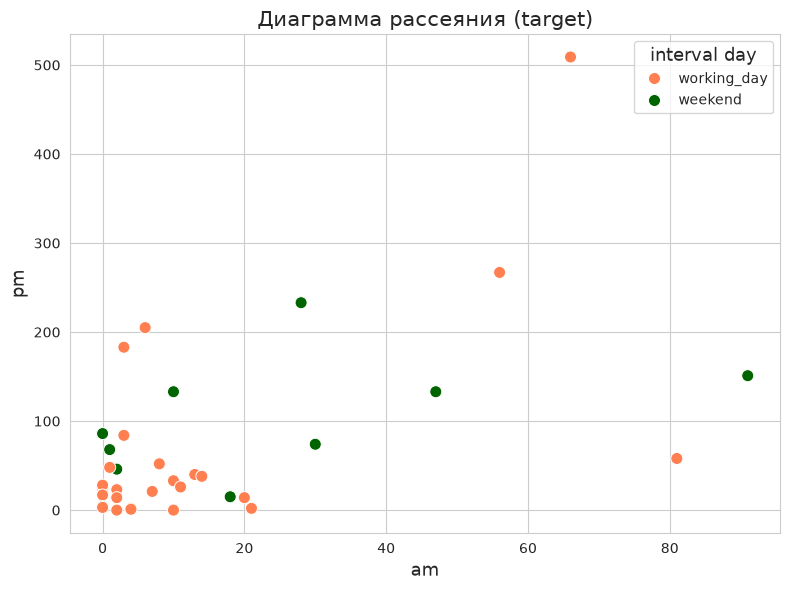

In [4]:
draw_scatterplot('target')

In [5]:
X = df[['am', 'pm']]
y = df['target']

model = LogisticRegression(random_state=21, fit_intercept=False)
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",21
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solv

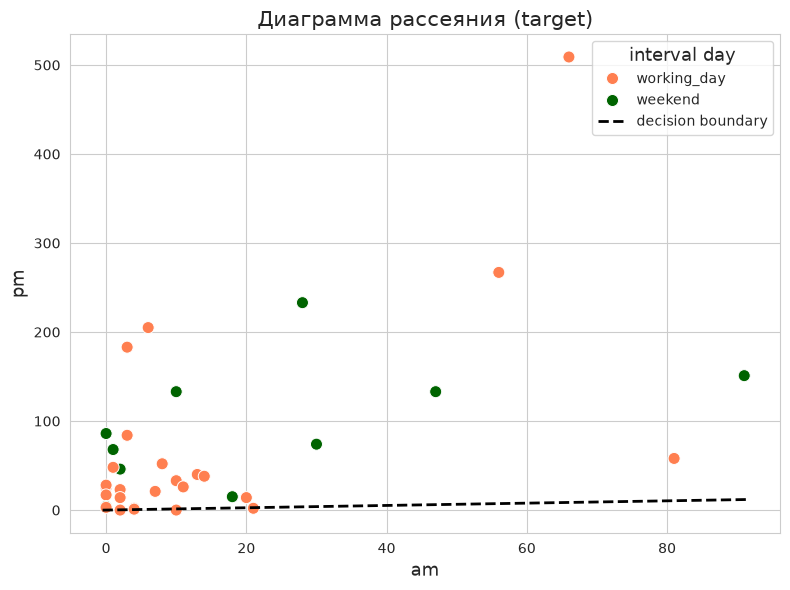

In [6]:
draw_scatterplot('target', model=model)

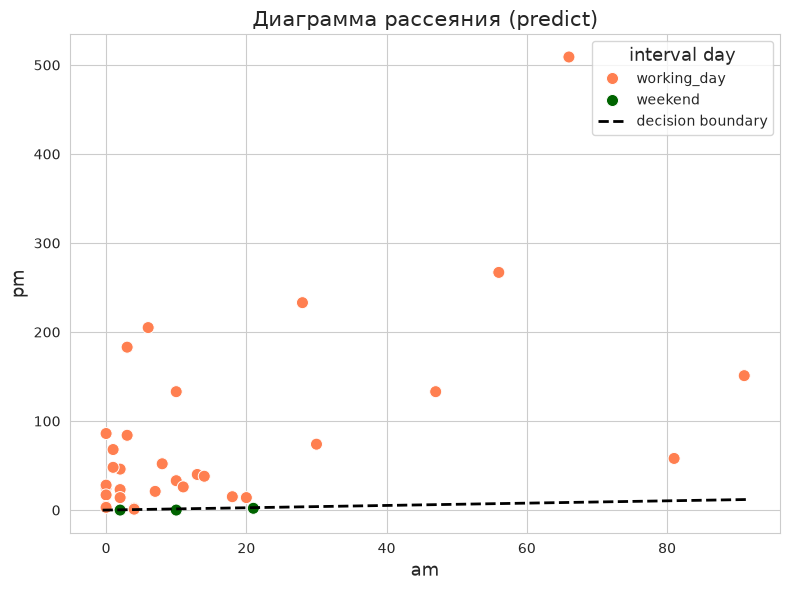

In [7]:
draw_scatterplot('predict', model=model)

## 2. Стандартизация и логистическая регрессия

Линейные модели чувствительны к масштабу переменных. Масштабирование признаков помогает модели проще находить оптимальное решение.

1. Применись StandardScaler к X и обучи логистическую регрессию снова с теми же параметрами.
2. Вычисли accuracy для новой модели. Стала ли она лучше наивного классификатора, предсказывающего самый частый класс?
3. Построй описанные выше графики, но уже для новой модели.

In [8]:
scaler = StandardScaler()

df[['am_scaled', 'pm_scaled']] = scaler.fit_transform(X)
X_scaled = df[['am_scaled', 'pm_scaled']]

In [9]:
model_scaled = LogisticRegression(random_state=21, fit_intercept=False)
model_scaled.fit(X_scaled, y)

,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",21
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solv

In [10]:
df['predict_scaled'] = model_scaled.predict(X_scaled)
print(f'Accuracy для predict_scaled: {accuracy_score(df['target'], df['predict_scaled'])}')

Accuracy для predict_scaled: 0.7428571428571429


In [11]:
most_popular_class = df['target'].mode()[0]
naive_predict = [most_popular_class] * len(df)
print(f'Accuracy для наивного предсказания: {accuracy_score(df['target'], naive_predict)}')

Accuracy для наивного предсказания: 0.7142857142857143


Она стала **чуть лучше** наивного классификатора

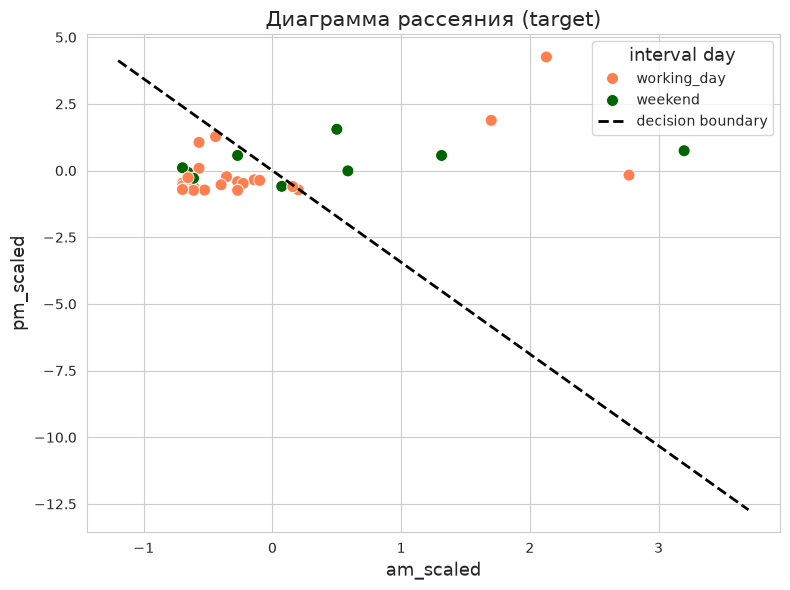

In [12]:
draw_scatterplot('target', x='am_scaled', y='pm_scaled', model=model_scaled)

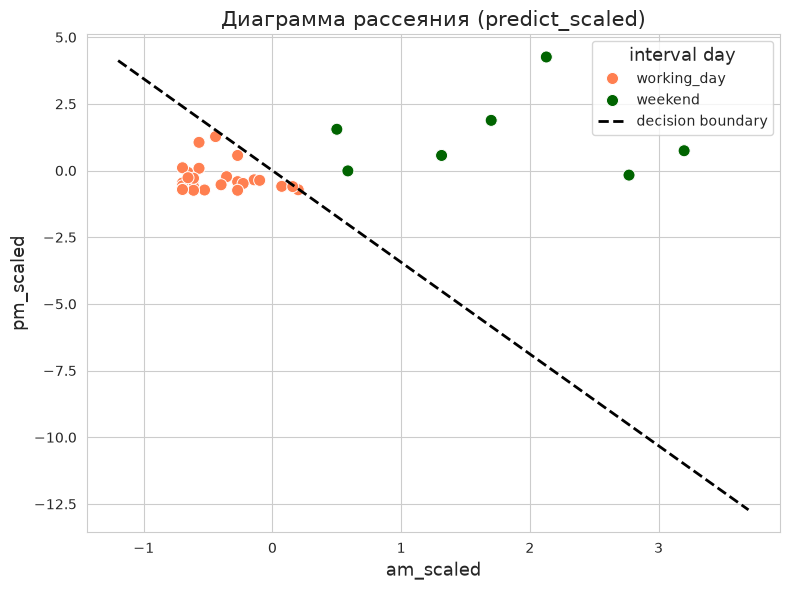

In [13]:
draw_scatterplot('predict_scaled', x='am_scaled', y='pm_scaled', model=model_scaled)

## 3. SVM

1. Применись модель SVC к масштабированному DataFrame с параметрами probability=True, random_state=21.
2. Вычисли accuracy.
3. Попробуй разные ядра и найди то, которое дает наилучшую точность.
4. Построй оба графика снова с границей решений, чтобы увидеть, как работает этот алгоритм.

In [14]:
kernels = ['sigmoid','linear', 'poly', 'rbf']

with warnings.catch_warnings():
    warnings.simplefilter('ignore', FutureWarning)
    for kernel in kernels:
        model_svc = SVC(kernel=kernel, probability=True, random_state=21)
        model_svc.fit(X_scaled, y)
        y_pred_svc = model_svc.predict(X_scaled)
        acc = accuracy_score(y, y_pred_svc)
        print(f'Accuracy для predict_svc с кернелом {kernel}: {acc}')

Accuracy для predict_svc с кернелом sigmoid: 0.6857142857142857
Accuracy для predict_svc с кернелом linear: 0.7142857142857143
Accuracy для predict_svc с кернелом poly: 0.7428571428571429
Accuracy для predict_svc с кернелом rbf: 0.7428571428571429


Доля верных ответов при кернелах poly и rbf оказалась одинаковой, возьмём по умолчанию rbf

In [15]:
df['predict_svc'] = y_pred_svc
df.head()

,date,am,pm,target,predict,am_scaled,pm_scaled,predict_scaled,predict_svc
0,2020-04-17,21,2,working_day,weekend,0.200690,-0.719904,working_day,working_day
1,2020-04-18,1,68,weekend,working_day,-0.655914,-0.071822,working_day,working_day
2,2020-04-19,18,15,weekend,working_day,0.072199,-0.592251,working_day,working_day
3,2020-04-20,2,23,working_day,working_day,-0.613084,-0.513696,working_day,working_day
4,2020-04-21,0,25,working_day,working_day,-0.698744,-0.494057,working_day,working_day


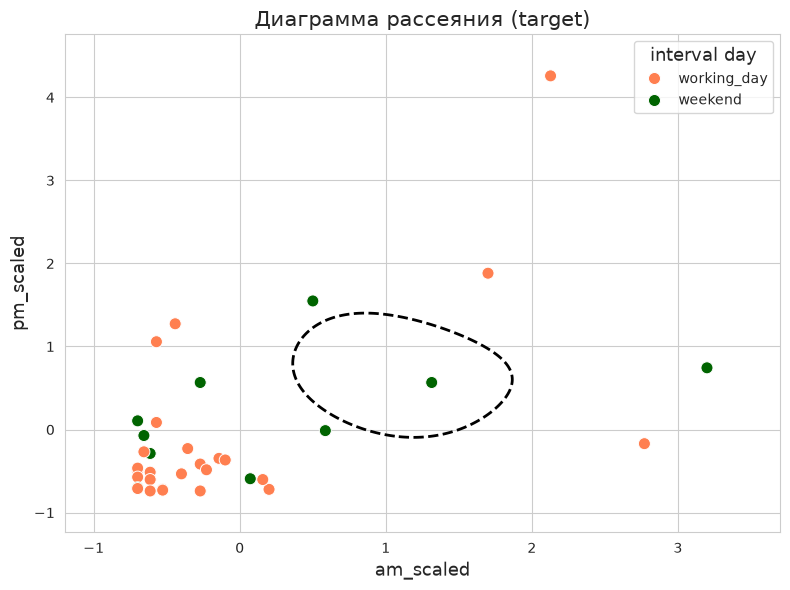

In [16]:
draw_scatterplot('target', x='am_scaled', y='pm_scaled', model=model_svc)

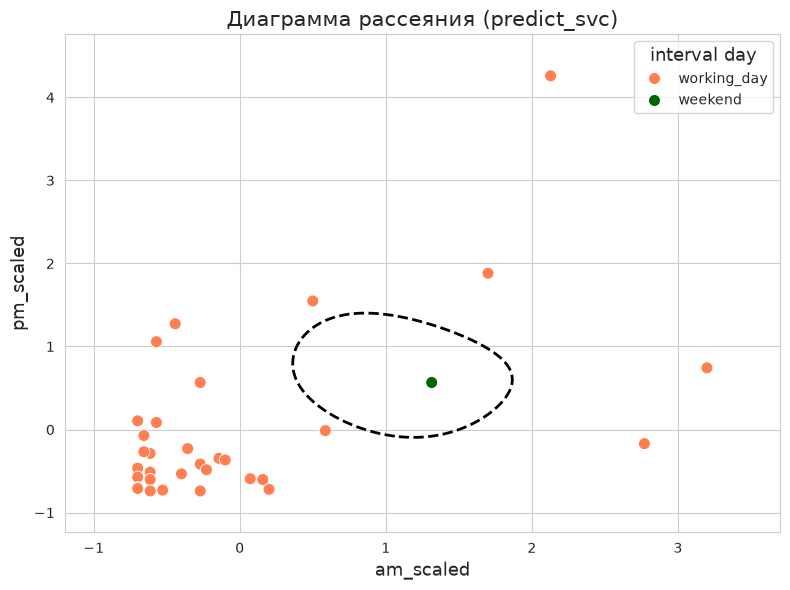

In [17]:
draw_scatterplot('predict_svc', x='am_scaled', y='pm_scaled', model=model_svc)

## 4. Дерево решений

1. Применись DecisionTreeClassifier к масштабированному DataFrame с параметрами max_depth=4, random_state=42.
2. Вычисли accuracy.
3. Попробуй разные значения max_depth.
4. Построй оба графика снова с границей решений, чтобы увидеть, как работает этот алгоритм.
5. С помощью метода .plot_tree() визуализируй само дерево решений. Это еще один способ понять, как работает алгоритм.
6. Сколько листьев на визуализированном дереве обозначают рабочие дни? Напиши ответ в markdown-ячейке в конце раздела.

In [18]:
model_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
model_tree.fit(X_scaled, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [19]:
df['predict_tree'] = model_tree.predict(X_scaled)
print(f'Accuracy для model_tree: {accuracy_score(df['target'], df['predict_tree'])}')

Accuracy для model_tree: 0.9428571428571428


In [20]:
for depth in range(1, 8):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_scaled, y)
    acc = accuracy_score(y, tree.predict(X_scaled))
    print(f'Accuracy для model_tree с max_depth={depth}: {acc}')

Accuracy для model_tree с max_depth=1: 0.7714285714285715
Accuracy для model_tree с max_depth=2: 0.8571428571428571
Accuracy для model_tree с max_depth=3: 0.8857142857142857
Accuracy для model_tree с max_depth=4: 0.9428571428571428
Accuracy для model_tree с max_depth=5: 0.9714285714285714
Accuracy для model_tree с max_depth=6: 1.0
Accuracy для model_tree с max_depth=7: 1.0


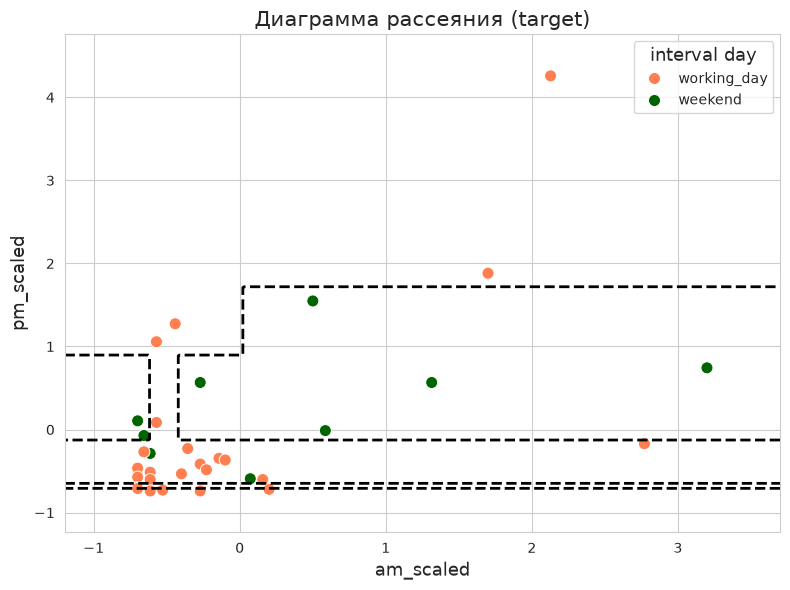

In [21]:
draw_scatterplot('target', x='am_scaled', y='pm_scaled', model=model_tree)

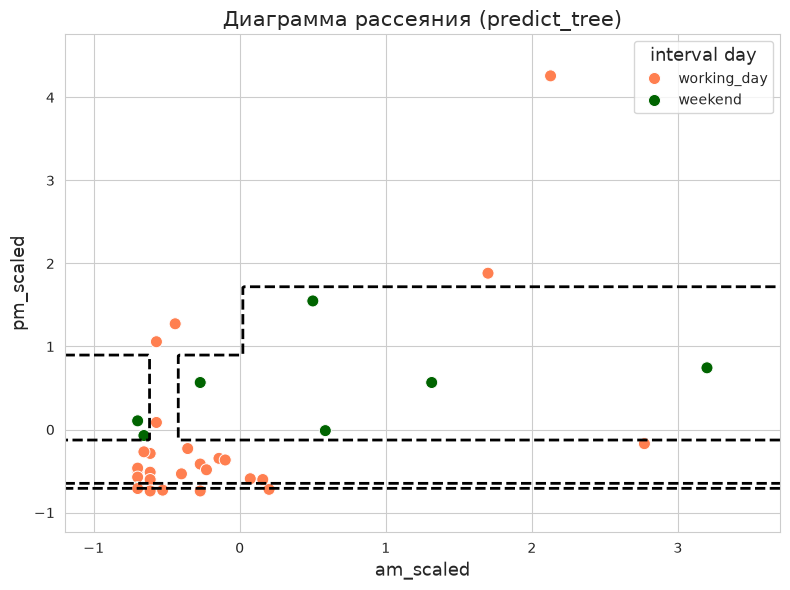

In [22]:
draw_scatterplot('predict_tree', x='am_scaled', y='pm_scaled', model=model_tree)

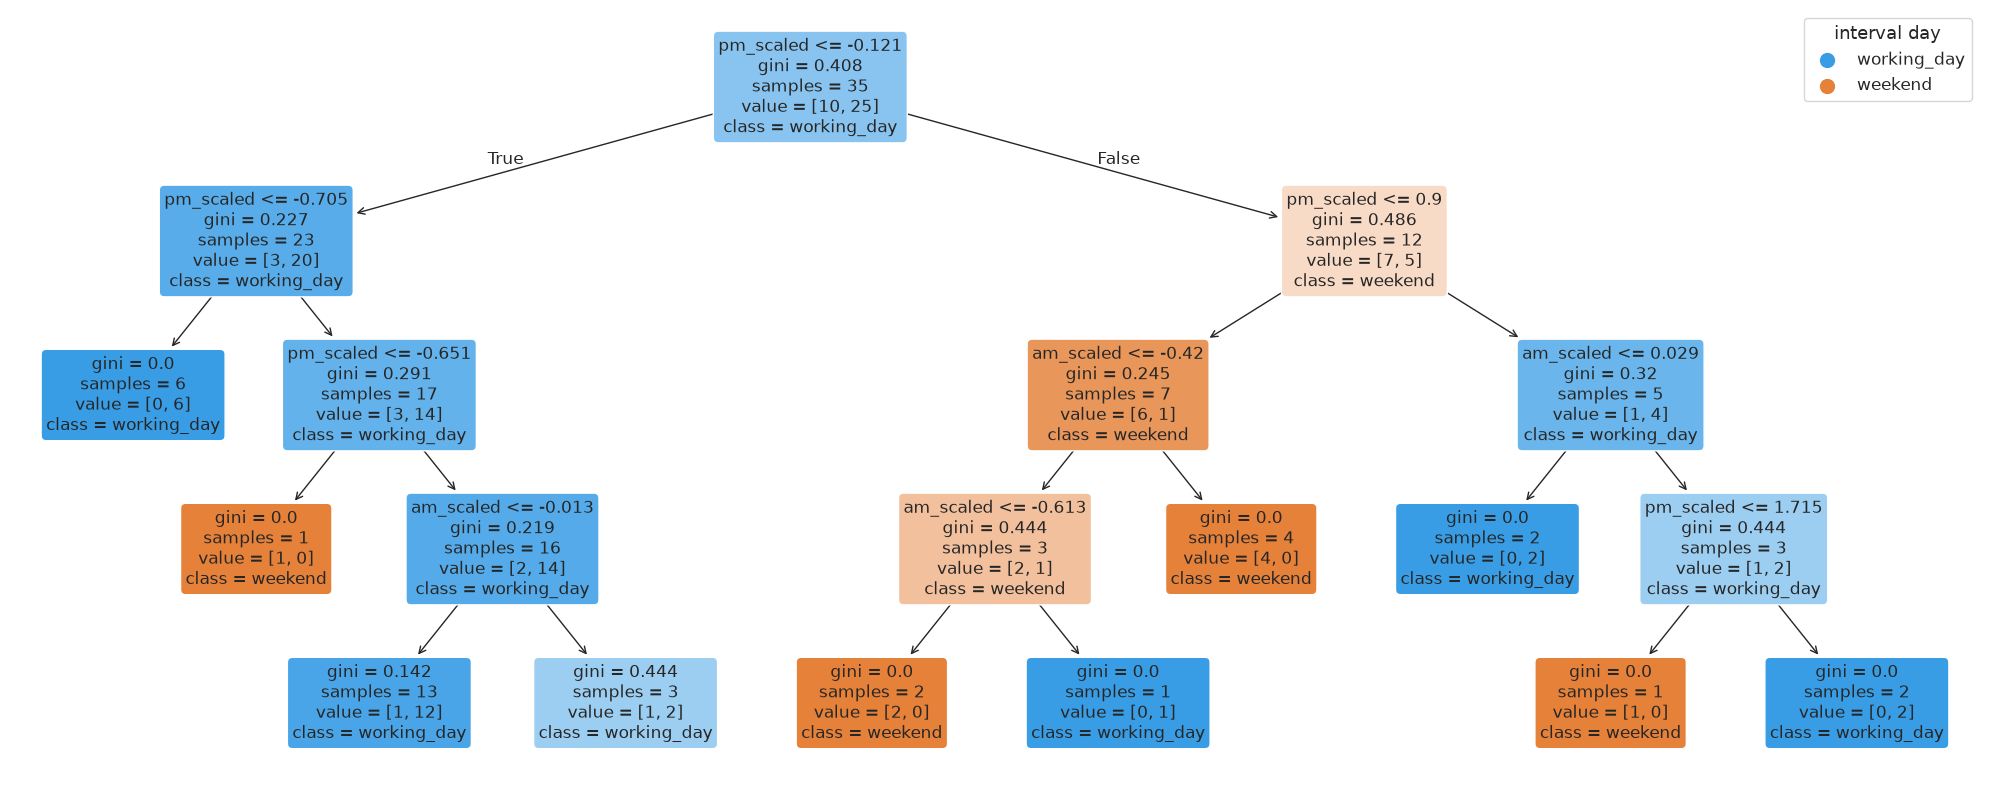

In [23]:
fig, ax = plt.subplots(figsize=(20, 8))
artists = plot_tree(
    model_tree,
    feature_names=['am_scaled', 'pm_scaled'],
    class_names=model_tree.classes_.tolist(),
    filled=True,
    rounded=True,
    ax=ax
)

seen = {}
for artist in reversed(artists):
    bbox = artist.get_bbox_patch()
    if bbox is None:
        continue
    text = artist.get_text()
    for class_name in model_tree.classes_:
        if f'class = {class_name}' in text and class_name not in seen:
            seen[class_name] = bbox.get_facecolor()

for label, color in seen.items():
    ax.scatter([], [], color=color, label=label, s=100)
ax.legend(title='interval day', fontsize=12, title_fontsize=13, loc='upper right')

plt.tight_layout()
plt.show()

**4 листа** обозначают рабочие дни с коэффициентом gini = 0 (полностью чистые листы)

а по правде листов 6